# Notebook 3 — Vocabulary & Lexical Diversity Over Time

In notebook 2 we discovered an unexpected pattern: median lexical diversity (MTLD) was ~45–50 in the late 1940s, crashed to ~25 from the 1960s through the 2010s, and is now climbing back toward 40 in the 2020s.

This notebook investigates that finding in depth:

1. Is it real or an artifact of sample size / language mix?
2. Does it hold up when we control for song length?
3. What words are *gained* and *lost* as diversity changes?
4. Is the recent recovery driven by specific artists or genres?
5. How does **vocabulary growth** (cumulative unique words across all hits) behave?

Key question this should answer: did pop music actually get linguistically simpler, or did it just get more repetitive within a stable vocabulary?

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
df = pd.read_parquet(PROCESSED_DIR / "songs_preprocessed.parquet")
# Restrict to English for vocabulary analysis (mixing languages would muddle results)
df_en = df[df["language"] == "en"].copy()
print(f"English songs: {len(df_en):,} of {len(df):,}")
df_en["decade"].value_counts().sort_index()

English songs: 6,538 of 6,696


decade
1940     82
1950    315
1960    911
1970    946
1980    978
1990    963
2000    967
2010    934
2020    442
Name: count, dtype: int64

## Sanity-check the MTLD pattern with confidence intervals

Wild swings in pre-1960 data might just be tiny-sample noise. We compute bootstrap confidence intervals for the median MTLD per year — if the early-years CI is huge, we should be cautious interpreting those points.

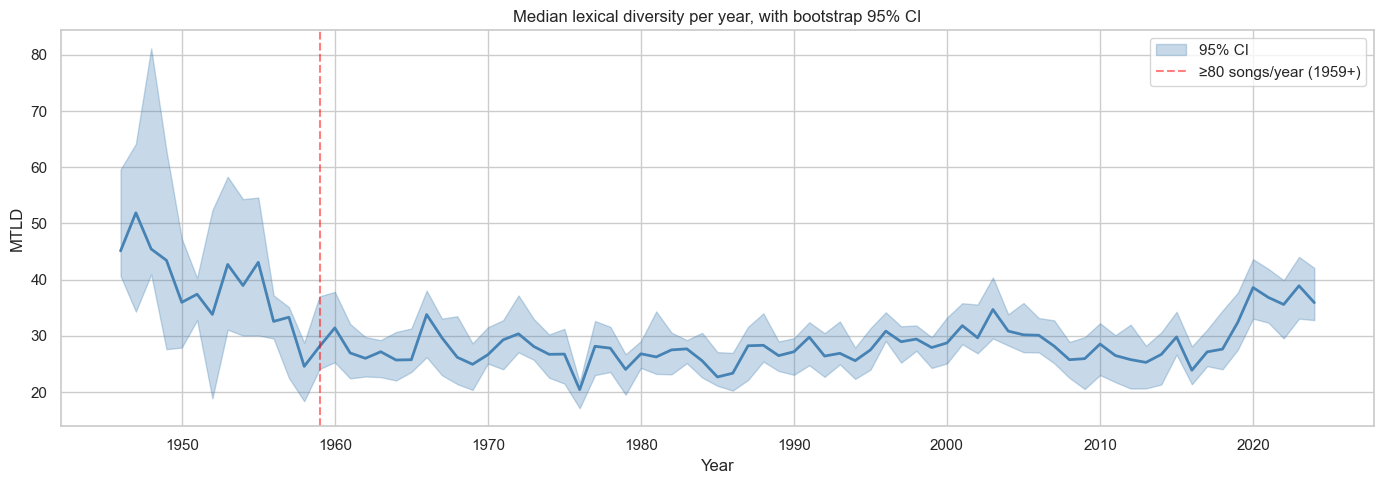

Reliable-data start: 1959
    year   n       mtld         lo         hi
0   1946  25  45.120136  40.661848  59.608716
1   1947  24  51.897436  34.323800  64.155730
2   1948  13  45.459622  40.964041  81.140613
3   1949  20  43.441806  27.640732  62.880203
4   1950  14  35.976246  27.935633  47.283666
5   1951  19  37.418539  32.802589  40.289509
6   1952   9  33.822678  18.892045  52.356889
7   1953  13  42.711679  31.115881  58.306892
8   1954  19  38.966693  30.067875  54.326454
9   1955  24  43.096100  30.076072  54.607692
10  1956  41  32.580972  29.549154  37.204387
11  1957  49  33.328165  22.528846  35.120865
12  1958  44  24.583722  18.382576  28.795128
13  1959  83  28.123250  24.113052  37.042596
14  1960  92  31.425557  25.314135  37.830935


In [2]:
def bootstrap_median_ci(values, n_boot=1000, ci=0.95):
    """Bootstrap confidence interval for the median."""
    values = np.asarray(values)
    if len(values) < 3:
        return np.nan, np.nan, np.nan
    medians = np.empty(n_boot)
    rng = np.random.default_rng(42)
    for i in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        medians[i] = np.median(sample)
    lo = np.percentile(medians, (1 - ci) / 2 * 100)
    hi = np.percentile(medians, (1 + ci) / 2 * 100)
    return np.median(values), lo, hi

# Per-year MTLD with CI
records = []
for year, group in df_en.groupby("year"):
    med, lo, hi = bootstrap_median_ci(group["mtld"].dropna())
    records.append({"year": year, "n": len(group), "mtld": med, "lo": lo, "hi": hi})

mtld_yearly = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(mtld_yearly["year"], mtld_yearly["lo"], mtld_yearly["hi"], 
                alpha=0.3, color="steelblue", label="95% CI")
ax.plot(mtld_yearly["year"], mtld_yearly["mtld"], color="steelblue", linewidth=2)

# Mark the year where sample size becomes reliable (>=80 songs/year)
reliable_start = mtld_yearly[mtld_yearly["n"] >= 80]["year"].min()
ax.axvline(reliable_start, color="red", linestyle="--", alpha=0.5,
           label=f"≥80 songs/year ({reliable_start}+)")

ax.set_title("Median lexical diversity per year, with bootstrap 95% CI")
ax.set_xlabel("Year"); ax.set_ylabel("MTLD")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Reliable-data start: {reliable_start}")
print(mtld_yearly.head(15))

## Control for length

MTLD is designed to be length-corrected, but let's verify by looking at MTLD as a function of token count. If they're tightly coupled, our "diversity over time" chart might actually be a "song length over time" chart.

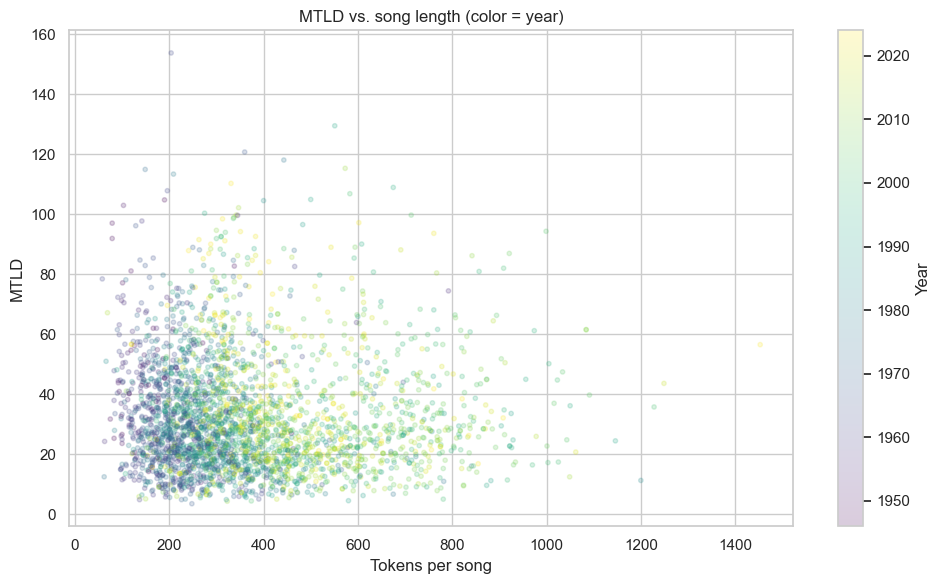

Correlation between n_tokens and MTLD: -0.044


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
sample = df_en.sample(min(3000, len(df_en)), random_state=42)
ax.scatter(sample["n_tokens"], sample["mtld"], alpha=0.2, s=10, c=sample["year"],
           cmap="viridis")
ax.set_xlabel("Tokens per song"); ax.set_ylabel("MTLD")
ax.set_title("MTLD vs. song length (color = year)")
cbar = plt.colorbar(ax.collections[0])
cbar.set_label("Year")
plt.tight_layout(); plt.show()

# Correlation
corr = df_en[["n_tokens", "mtld"]].corr().iloc[0, 1]
print(f"Correlation between n_tokens and MTLD: {corr:.3f}")

## Vocabulary frontier: when did pop music "exhaust" new words?

A different angle: as we walk year by year through hit songs, how fast does the **cumulative vocabulary** grow? If most years introduce ~50 new words to the corpus, the language is being expanded. If years introduce ~5 new words, songwriters are reusing existing vocabulary.

This is influenced by sample size (more songs = more new words mechanically), so we compute it per-song-normalized.

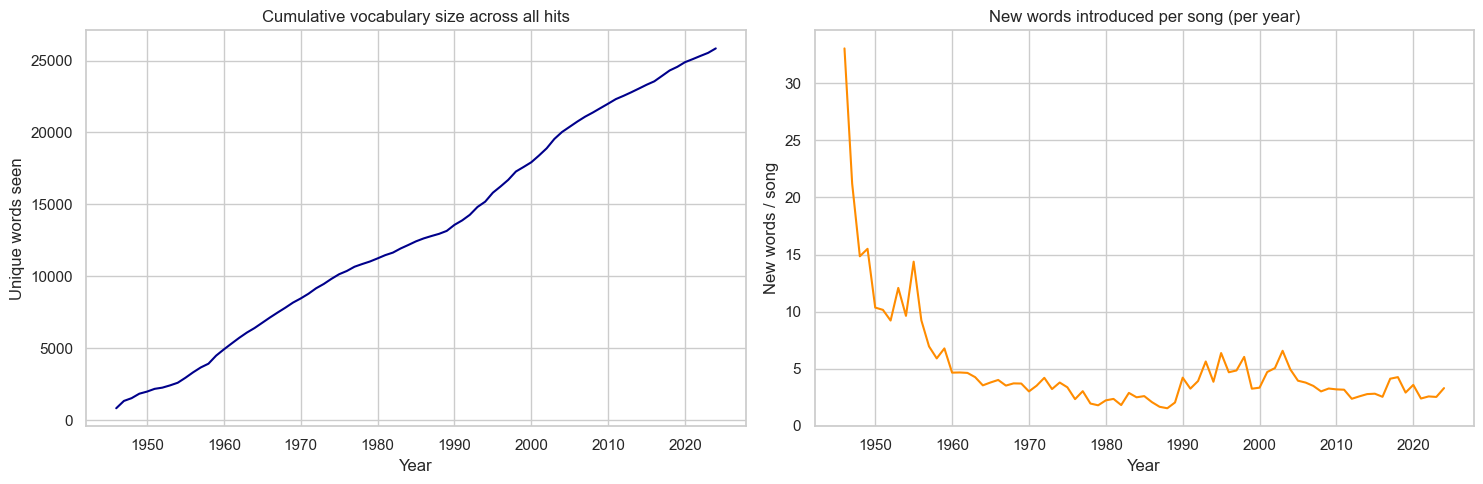


Total vocabulary across all hits: 25,845 unique words

Top 10 years for vocabulary expansion (new words per song):
    year  new_words_per_song  n_songs
0   1946           33.040000       25
1   1947           21.208333       24
3   1949           15.500000       20
2   1948           14.846154       13
9   1955           14.375000       24
7   1953           12.076923       13
4   1950           10.357143       14
5   1951           10.157895       19
8   1954            9.631579       19
10  1956            9.243902       41


In [4]:
# Sort by year, walk through, track cumulative vocabulary
df_sorted = df_en.sort_values(["year", "rank"]).reset_index(drop=True)
seen_vocab = set()
new_per_song = []
cumulative = []

for _, row in df_sorted.iterrows():
    song_vocab = set(row["tokens"])
    new = song_vocab - seen_vocab
    new_per_song.append(len(new))
    seen_vocab |= song_vocab
    cumulative.append(len(seen_vocab))

df_sorted["new_words"] = new_per_song
df_sorted["cumulative_vocab"] = cumulative

# Per-year aggregates
yearly_vocab = df_sorted.groupby("year").agg(
    new_words_per_song=("new_words", "mean"),
    cumulative=("cumulative_vocab", "last"),
    n_songs=("id", "count"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(yearly_vocab["year"], yearly_vocab["cumulative"], color="darkblue")
axes[0].set_title("Cumulative vocabulary size across all hits")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Unique words seen")

axes[1].plot(yearly_vocab["year"], yearly_vocab["new_words_per_song"], color="darkorange")
axes[1].set_title("New words introduced per song (per year)")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("New words / song")

plt.tight_layout(); plt.show()

print(f"\nTotal vocabulary across all hits: {len(seen_vocab):,} unique words")
print(f"\nTop 10 years for vocabulary expansion (new words per song):")
print(yearly_vocab.nlargest(10, "new_words_per_song")[["year", "new_words_per_song", "n_songs"]])

## Word-level: which words are gaining and losing ground?

Compare the most-distinctive words for two periods. We use **log odds ratio with informative prior** (Monroe et al. 2008) — a more principled approach than raw frequency comparison, since it down-weights words that are uncommon overall.

We compare 1960s–1980s ("the diversity dip") vs 2020s ("the recovery").

In [5]:
def word_counts(token_lists):
    """Sum token counts across a list of token lists."""
    counter = Counter()
    for toks in token_lists:
        counter.update(toks)
    return counter

period_a = df_en[df_en["decade"].between(1960, 1980)]
period_b = df_en[df_en["decade"] >= 2020]

counts_a = word_counts(period_a["tokens"])
counts_b = word_counts(period_b["tokens"])
counts_all = counts_a + counts_b

# Log odds ratio with Dirichlet prior (Monroe et al.)
def log_odds(counts_a, counts_b, prior):
    n_a, n_b, n_prior = sum(counts_a.values()), sum(counts_b.values()), sum(prior.values())
    results = {}
    for word in set(counts_a) | set(counts_b):
        a_i, b_i, p_i = counts_a.get(word, 0), counts_b.get(word, 0), prior.get(word, 0)
        if a_i + b_i + p_i < 30:  # filter rare words
            continue
        # Log odds with prior
        lo = np.log((a_i + p_i) / (n_a + n_prior - a_i - p_i)) - \
             np.log((b_i + p_i) / (n_b + n_prior - b_i - p_i))
        # Variance and z-score
        var = 1/(a_i + p_i) + 1/(b_i + p_i)
        z = lo / np.sqrt(var)
        results[word] = z
    return results

scores = log_odds(counts_a, counts_b, counts_all)
scored = pd.Series(scores).sort_values()

print("Top 25 words MORE characteristic of 2020s (vs 1960-80s):")
print(scored.head(25))
print("\nTop 25 words MORE characteristic of 1960-80s (vs 2020s):")
print(scored.tail(25)[::-1])

Top 25 words MORE characteristic of 2020s (vs 1960-80s):
shit        -19.735466
fuck        -18.654948
bitch       -18.352309
nigga       -16.872074
ayy         -13.420332
ass         -13.166246
gon         -12.959251
niggas      -12.802217
tryna       -12.641873
ain't       -11.962311
like        -11.902684
i'ma        -11.717519
lil         -11.523577
damn        -11.059105
i           -11.040721
christmas   -10.641317
boaw        -10.607120
up          -10.317090
bam          -9.861469
nah          -9.264041
pussy        -9.118876
yeah         -8.933766
bitches      -8.892519
i'm          -8.731756
bout         -8.602119
dtype: float64

Top 25 words MORE characteristic of 1960-80s (vs 2020s):
love      15.158053
gonna      8.159418
to         8.083270
will       7.621679
oh         7.556965
baby       6.075728
and        5.704149
are        5.673667
come       5.636803
little     5.556144
na         5.539353
sweet      5.430004
is         5.347420
hey        5.320450
away       5.17

## Visual: vocabulary churn

How much do the most common words turn over from decade to decade? This shows whether pop music recycles the same core vocabulary or constantly refreshes it.

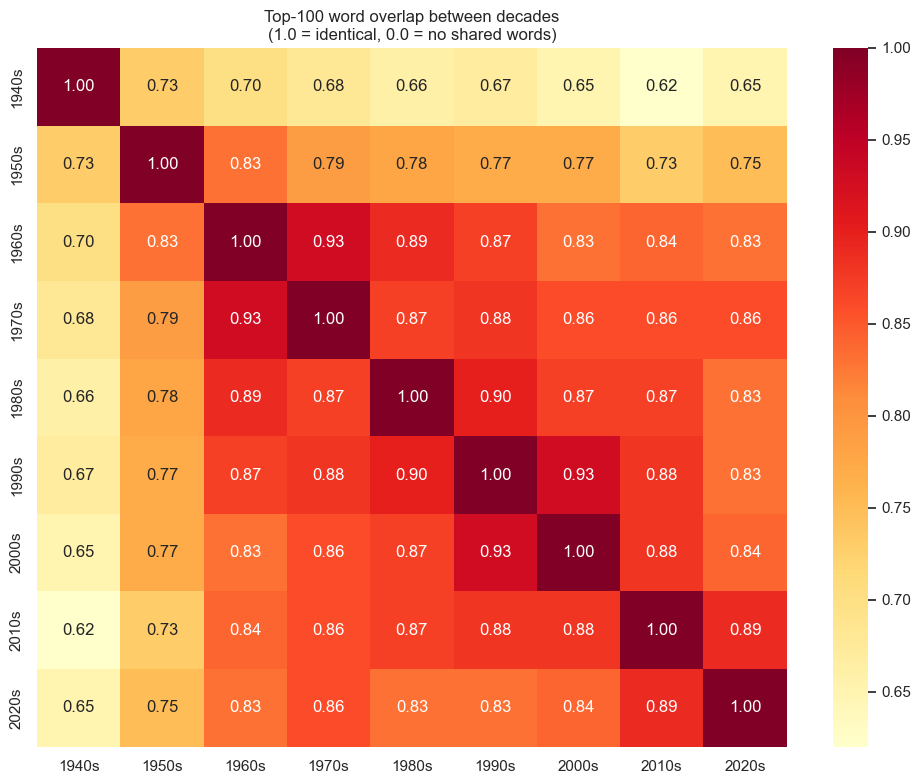


Words in top-100 of EVERY decade since 1950 (67):
['a', 'all', 'and', 'at', 'baby', 'be', 'but', 'can', "can't", 'cause', 'come', 'do', "don't", 'down', 'for', 'get', 'go', 'got', 'have', 'how', 'i', "i'll", "i'm", 'if', 'in', 'is', 'it', "it's", 'just', 'know', 'let', 'like', 'love', 'make', 'me', 'my', 'never', 'no', 'now', 'of', 'oh', 'on', 'one', 'ooh', 'say', 'see', 'she', 'so', 'tell', 'that', 'the', 'they', 'this', 'time', 'to', 'up', 'want', 'was', 'way', 'we', 'what', 'when', 'with', 'yeah', 'you', "you're", 'your']


In [6]:
# Top 100 words per decade
decade_top = {}
for decade, group in df_en.groupby("decade"):
    counter = word_counts(group["tokens"])
    decade_top[decade] = set([w for w, _ in counter.most_common(100)])

decades = sorted(decade_top.keys())
overlap_matrix = np.zeros((len(decades), len(decades)))
for i, d1 in enumerate(decades):
    for j, d2 in enumerate(decades):
        if decade_top[d1] and decade_top[d2]:
            overlap_matrix[i, j] = len(decade_top[d1] & decade_top[d2]) / 100

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(overlap_matrix, annot=True, fmt=".2f",
            xticklabels=[f"{d}s" for d in decades],
            yticklabels=[f"{d}s" for d in decades],
            cmap="YlOrRd", ax=ax)
ax.set_title("Top-100 word overlap between decades\n(1.0 = identical, 0.0 = no shared words)")
plt.tight_layout(); plt.show()

# Words present in every decade — the "permanent" pop vocabulary
permanent = set.intersection(*[decade_top[d] for d in decades if d >= 1950])
print(f"\nWords in top-100 of EVERY decade since 1950 ({len(permanent)}):")
print(sorted(permanent))